# nb04 — робот против биткоина

Вопрос пользователя: как **направление** и **волатильность BTC** влияют на результаты робота.
Смотрим три вещи (всё считаем движком/данными в ячейках):
1. **Рыночная нейтральность:** корреляция и бета дневной доходности робота к BTC. Робот — это
   mean-reversion на альтах с двумя противоположными ногами; ожидаем низкую бету.
2. **Направление BTC:** как робот идёт в BTC-рост / BTC-падение (по дням и по тренду).
3. **Волатильность BTC:** высокая вола = больше событий (возможность) или больше риска?
Плюс разложение по ногам: где памп-шорты страдают (мелт-ап?), где дамп-лонги (крах?).

In [1]:
import sys; sys.path.insert(0, ".")
from _engine import load_signals, build_book, run_dca
from _lab import ohlcv, show
import numpy as np, pandas as pd

PUMP, DUMP = load_signals()
BOOK = build_book(PUMP, DUMP)
R = run_dca(BOOK, f_pump=0.05, f_dump=0.03)          # агрессивный эталон
nav = R["nav"]; rob = nav.pct_change().dropna()*100   # дневная доходность робота, %

# ── BTC дневные признаки ─────────────────────────────────────────────────────
btc = ohlcv("BTCUSDT","2024-01-01","2026-07-01","1d")["close"]
btc.index = btc.index.tz_localize(None) if btc.index.tz is not None else btc.index
bret = btc.pct_change()*100                            # дневная доходность BTC, %
bvol = bret.rolling(14).std()*np.sqrt(365)             # 14д реализованная вола BTC (годовая), %  (каузально)
btrend30 = (btc/btc.shift(30)-1)*100                   # 30д тренд BTC, % (каузально)
B = pd.DataFrame({"btc_ret":bret,"btc_vol":bvol,"btc_trend30":btrend30,"btc_px":btc}).dropna()
print(f"робот-дней {len(rob)}, BTC-дней {len(B)}")
print(f"BTC за период: старт ${btc.iloc[0]:,.0f} -> финал ${btc.iloc[-1]:,.0f}  ({(btc.iloc[-1]/btc.iloc[0]-1)*100:+.0f}%)")
print(f"BTC вола (годовая) median {bvol.median():.0f}%  диапазон {bvol.min():.0f}..{bvol.max():.0f}%")

робот-дней 911, BTC-дней 882
BTC за период: старт $44,236 -> финал $58,604  (+32%)
BTC вола (годовая) median 42%  диапазон 15..111%


## 1. Рыночная нейтральность: корреляция и бета робота к BTC

In [2]:
df = pd.DataFrame({"rob":rob}).join(B, how="inner").dropna()
beta, alpha = np.polyfit(df.btc_ret, df.rob, 1)
corr = df.rob.corr(df.btc_ret)
print(f"corr(робот, BTC) дневная = {corr:+.2f}")
print(f"бета робота к BTC = {beta:+.3f}  (|бета|<<1 = почти рыночно-нейтрален)")
print(f"альфа (сдвиг) = {alpha:+.3f}%/день  ~ {alpha*365:+.0f}%/год в идеале")
print(f"робот: средняя {df.rob.mean():+.3f}%/день, std {df.rob.std():.2f}%  | BTC: {df.btc_ret.mean():+.3f}%/день, std {df.btc_ret.std():.2f}%")

corr(робот, BTC) дневная = -0.10
бета робота к BTC = -0.079  (|бета|<<1 = почти рыночно-нейтрален)
альфа (сдвиг) = +0.299%/день  ~ +109%/год в идеале
робот: средняя +0.293%/день, std 1.92%  | BTC: +0.067%/день, std 2.51%


## 2. Направление BTC: робот в рост / падение / тренды

In [3]:
print("=== по знаку дня BTC ===")
for lab,mask in [("BTC день ВВЕРХ", df.btc_ret>0),("BTC день ВНИЗ", df.btc_ret<0)]:
    s=df.rob[mask]; print(f"  {lab:16s} (n={mask.sum():3d}): робот mean {s.mean():+.3f}%/день  win {(s>0).mean()*100:.0f}%  std {s.std():.2f}%")
print("\n=== по 30-дн тренду BTC (терцили) ===")
df["treg"]=pd.qcut(df.btc_trend30,3,labels=["bear (низ 1/3)","chop (сред)","bull (верх 1/3)"])
g=df.groupby("treg",observed=True).agg(days=("rob","size"),rob_mean=("rob","mean"),rob_win=("rob",lambda x:(x>0).mean()*100),
    rob_sharpe=("rob",lambda x:x.mean()/x.std()*np.sqrt(365)),btc_mean=("btc_ret","mean"))
print(g.round(3).to_string())

=== по знаку дня BTC ===
  BTC день ВВЕРХ   (n=444): робот mean +0.104%/день  win 63%  std 1.80%
  BTC день ВНИЗ    (n=438): робот mean +0.485%/день  win 65%  std 2.01%

=== по 30-дн тренду BTC (терцили) ===
                 days  rob_mean  rob_win  rob_sharpe  btc_mean
treg                                                          
bear (низ 1/3)    294     0.460   64.966       3.822    -0.506
chop (сред)       294    -0.071   57.823      -0.857     0.128
bull (верх 1/3)   294     0.492   69.048       5.374     0.579


## 3. Волатильность BTC: возможность или риск?

Разбиваем дни на квартили по BTC-воле; в каждом — доходность робота и АКТИВНОСТЬ (число событий по
вселенной в этот день).

In [4]:
# активность: события/день по всей сигнальной вселенной
allev = pd.concat([PUMP["entry"], DUMP["entry"]])
ev_day = allev.dt.floor("D").value_counts().sort_index()
df["events"] = ev_day.reindex(df.index).fillna(0).values
df["volq"] = pd.qcut(df.btc_vol,4,labels=["Q1 низкая","Q2","Q3","Q4 высокая"])
g=df.groupby("volq",observed=True).agg(days=("rob","size"),btc_vol=("btc_vol","mean"),events_day=("events","mean"),
    rob_mean=("rob","mean"),rob_sharpe=("rob",lambda x:x.mean()/x.std()*np.sqrt(365)),
    rob_worst=("rob","min"),btc_mean=("btc_ret","mean"))
print("=== робот по квартилям BTC-волы ===")
print(g.round(2).to_string())

=== робот по квартилям BTC-волы ===
            days  btc_vol  events_day  rob_mean  rob_sharpe  rob_worst  btc_mean
volq                                                                            
Q1 низкая    221    26.90       11.94      0.20        3.11      -5.66      0.11
Q2           220    37.24       14.46      0.18        2.68      -6.43     -0.19
Q3           220    45.95       18.71      0.35        3.78     -13.76     -0.17
Q4 высокая   221    68.67       33.16      0.44        2.92      -9.27      0.51


## 4. Разложение по ногам: BTC-состояние в момент входа сделки

Каждой сделке ставим в соответствие состояние BTC её дня входа (знак дня и волу, каузально) и смотрим
per-trade pnl пампа и дампа. Так видно, какая нога страдает в каком режиме.

In [5]:
bd = BOOK.copy(); bd["day"]=bd["entry"].dt.floor("D")
bmap = B.reindex(pd.to_datetime(sorted(set(bd["day"])))).ffill()
bd = bd.join(bmap[["btc_ret","btc_vol"]], on="day")
bd["btc_dir"]=np.where(bd.btc_ret>0,"BTC вверх","BTC вниз")
bd["btc_volh"]=np.where(bd.btc_vol>=bd.btc_vol.median(),"вола ВЫС","вола НИЗ")
print("per-trade pnl по ноге × направление BTC (день входа):")
print(bd.groupby(["stream","btc_dir"],observed=True).agg(n=("pnl","size"),mean=("pnl",lambda x:x.mean()*100),
    median=("pnl",lambda x:x.median()*100),win=("pnl",lambda x:(x>0).mean()*100)).round(2).to_string())
print("\nper-trade pnl по ноге × вола BTC:")
print(bd.groupby(["stream","btc_volh"],observed=True).agg(n=("pnl","size"),mean=("pnl",lambda x:x.mean()*100),
    median=("pnl",lambda x:x.median()*100),win=("pnl",lambda x:(x>0).mean()*100)).round(2).to_string())

per-trade pnl по ноге × направление BTC (день входа):
                     n  mean  median    win
stream btc_dir                             
dump   BTC вверх  1109  4.27    4.93  74.03
       BTC вниз   3176  5.28    4.01  71.69
pump   BTC вверх  4751  0.12    1.20  58.83
       BTC вниз   5473  0.18    0.94  55.80

per-trade pnl по ноге × вола BTC:
                    n  mean  median    win
stream btc_volh                           
dump   вола ВЫС  2015  5.80    4.55  71.02
       вола НИЗ  2270  4.33    3.99  73.44
pump   вола ВЫС  4755 -0.39    0.52  53.40
       вола НИЗ  5469  0.62    1.50  60.52


[saved] notebooks\pump_dump_v2\_out\v2_nb04_btc.png


WindowsPath('C:/projects/researchlab/notebooks/pump_dump_v2/_out/v2_nb04_btc.png')

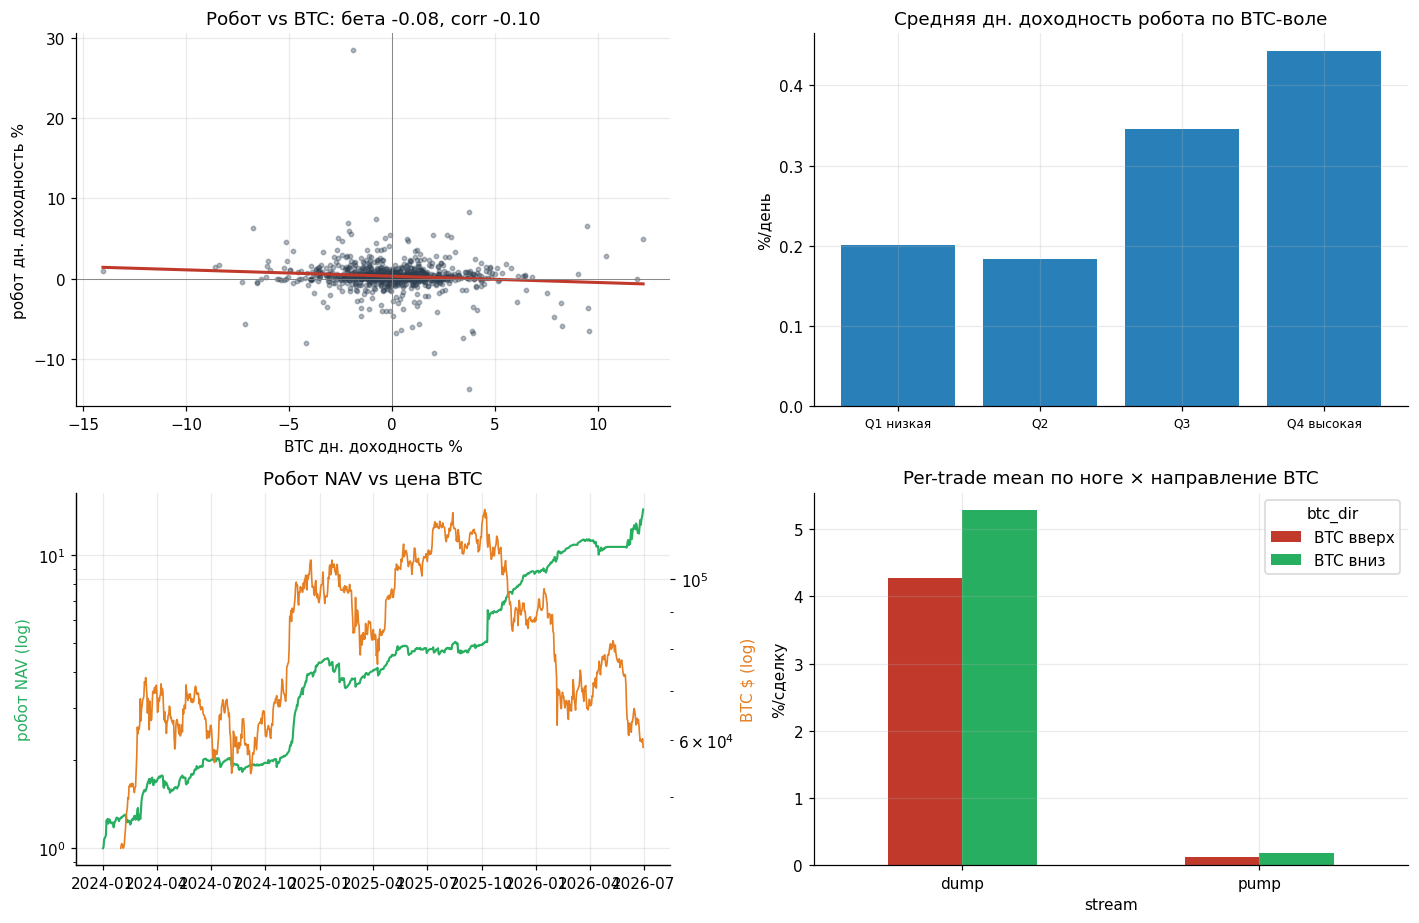

In [6]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(2,2,figsize=(13,8.5))
# (1) scatter робот vs BTC
ax[0,0].scatter(df.btc_ret,df.rob,s=8,alpha=.35,color="#2c3e50")
xs=np.linspace(df.btc_ret.min(),df.btc_ret.max(),50); ax[0,0].plot(xs,beta*xs+alpha,color="#c0392b",lw=2)
ax[0,0].axhline(0,color="grey",lw=.6); ax[0,0].axvline(0,color="grey",lw=.6)
ax[0,0].set_xlabel("BTC дн. доходность %"); ax[0,0].set_ylabel("робот дн. доходность %")
ax[0,0].set_title(f"Робот vs BTC: бета {beta:+.2f}, corr {corr:+.2f}")
# (2) робот mean по BTC-воле квартилям
gg=df.groupby("volq",observed=True).rob.mean()
ax[0,1].bar(range(4),gg.values,color="#2980b9"); ax[0,1].set_xticks(range(4)); ax[0,1].set_xticklabels(gg.index,fontsize=8)
ax[0,1].set_title("Средняя дн. доходность робота по BTC-воле"); ax[0,1].set_ylabel("%/день"); ax[0,1].axhline(0,color="grey",lw=.6)
# (3) робот NAV vs BTC цена во времени
axr=ax[1,0]; axr.plot(nav.index,nav.values,color="#27ae60",lw=1.4,label="робот NAV")
axr.set_yscale("log"); axr.set_ylabel("робот NAV (log)",color="#27ae60"); axb=axr.twinx()
axb.plot(B.index,B.btc_px,color="#e67e22",lw=1.1,label="BTC $"); axb.set_yscale("log"); axb.set_ylabel("BTC $ (log)",color="#e67e22")
axr.set_title("Робот NAV vs цена BTC")
# (4) per-leg mean по направлению BTC
piv=bd.groupby(["stream","btc_dir"],observed=True).pnl.mean().unstack()*100
piv.plot(kind="bar",ax=ax[1,1],color=["#c0392b","#27ae60"]); ax[1,1].set_title("Per-trade mean по ноге × направление BTC")
ax[1,1].set_ylabel("%/сделку"); ax[1,1].axhline(0,color="grey",lw=.6); ax[1,1].tick_params(axis="x",rotation=0)
show("v2_nb04_btc")

## Выводы (числа — из ячеек выше)

**1. Робот почти рыночно-нейтрален к BTC.** corr −0.10, **бета −0.08** — доходность робота практически
не зависит от BTC (даже слегка ПРОТИВ). Наглядно (график НАВ vs BTC): в конце 2025→2026 BTC рухнул
(~$120k→$58k), а NAV робота ровно лез вверх. Это альфа-движок на альтах, не ставка на биток.

**2. Направление BTC: враг — не направление, а БОКОВИК.** Робот в BTC-down дни даже ЛУЧШЕ (+0.49%/день),
чем в up-дни (+0.10%) — дамп-лонги ловят больше отскоков на падениях. По 30-дн тренду: **bear Sharpe 3.82,
bull 5.37, а chop (боковик) −0.86** (единственный убыточный режим). Пампы/дампы — это резкие 15-мин движения;
они есть в трендах (в любую сторону), но пропадают в вялом боковике + там больше ложных срабатываний.

**3. Волатильность BTC: больше волы → больше возможностей И риска.** От Q1 к Q4 волы события/день растут
**12→33**, средняя доходность **+0.20→+0.44%/день**, но worst-день ухудшается (−5.7%→−9.3%) и Sharpe чуть
ниже (пик Sharpe 3.78 на Q3 = умеренно-высокая вола — золотая середина). Высокая вола BTC = топливо стратегии.

**4. Ноги противоположны по воле — это хедж в пространстве волатильности:**
- **Дамп любит высокую волу / падения:** mean +5.8% (вола ВЫС) vs +4.3% (НИЗ); +5.3% (BTC вниз) vs +4.3% (вверх).
- **Памп любит низкую волу / спокойствие:** mean **+0.62% (вола НИЗ) → −0.39% (вола ВЫС)** — в высоковолатильном
  мелт-апе памп-шорты переезжают раннеры. Памп-шорт лучше всего работает в тихом рынке.
- Итог: дамп несёт результат в турбулентности, памп — в штиле → вместе сглаживают по всем режимам волы
  (тот же хедж-механизм, что и корр −0.5 из nb00, но теперь виден в разрезе BTC-волы).

**Практика:** робот — рыночно-нейтральная альфа; масштабировать активность в турбулентные/трендовые
режимы BTC, поберечься в затяжном боковике (единственный отрицательный режим). Оговорки: один BTC-цикл
2024–26, in-sample, «chop=плохо» опирается на ~294 дня.